<a href="https://colab.research.google.com/github/Khizer45/Skyntri/blob/main/ML_Assignment_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Assignment 1
## Model Analysis and Hyperparameter Optimization




**Dataset:** Spam Email Classification  
**Models:** K-Nearest Neighbors (KNN) & Naive Bayes (Gaussian + Multinomial)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
print("All libraries imported successfully.")

All libraries imported successfully.


---
## Data Loading & Exploratory Data Analysis

The **Spam Email Dataset** contains 3,000 emails with 10 numeric features capturing structural
and behavioral email properties. Target label: **0 = Ham, 1 = Spam**.


In [2]:
# Helper Function
def save_cm(y_true, y_pred, title, labels=('Ham','Spam')):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    return cm

def metrics_row(name, y_true, y_pred):
    return {'Model': name,
            'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
            'F1-Score':  round(f1_score(y_true, y_pred),        4),
            'Precision': round(precision_score(y_true, y_pred), 4),
            'Recall':    round(recall_score(y_true, y_pred),    4)}

print("Helper functions defined.")

Helper functions defined.


In [3]:
#  LOAD & EXPLORE DATA

df = pd.read_csv('/content/spam_email_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nLabel Distribution:")
print(df['label'].value_counts().rename({0:'Ham (0)', 1:'Spam (1)'}))
print(f"\nMissing Values: {df.isnull().sum().sum()}")
df.head()

Dataset Shape: (3000, 16)

Label Distribution:
label
Ham (0)     1800
Spam (1)    1200
Name: count, dtype: int64

Missing Values: 0


,email_id,sender_email,sender_domain,subject,email_text,num_links,num_images,has_attachment,email_length,caps_ratio,special_chars,word_count,exclamation_count,contains_html,time_sent_hour,label
0,EMAIL_00601,user601@yahoo.com,yahoo.com,Team update,Please review attached.,3,1,0,658,0.2046,13,203,0,0,11,0
1,EMAIL_01190,user1190@clickhere.com,clickhere.com,You have won!,Click here to claim your prize!,4,0,0,743,0.0000,8,185,2,0,10,1
2,EMAIL_00617,user617@company.org,company.org,Team update,Please review attached.,4,3,0,622,0.1294,12,189,0,0,8,0
3,EMAIL_00251,user251@clickhere.com,clickhere.com,You have won!,Click here to claim your prize!,10,5,1,294,0.2346,21,19,10,1,3,1
4,EMAIL_01305,user1305@gmail.com,gmail.com,Team update,Please review attached.,0,0,1,557,0.1727,11,191,0,0,16,0


In [4]:
# Dataset statistics
df.describe().round(3)

,num_links,num_images,has_attachment,email_length,caps_ratio,special_chars,word_count,exclamation_count,contains_html,time_sent_hour,label
count,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.000,3000.00
mean,5.806,2.506,0.363,453.508,0.162,13.234,125.732,3.993,0.498,11.627,0.40
std,5.442,2.413,0.481,188.294,0.137,10.920,69.777,3.887,0.500,6.567,0.49
min,0.000,0.000,0.000,50.000,0.000,0.000,5.000,0.000,0.000,2.000,0.00
25%,1.000,0.000,0.000,268.000,0.035,3.000,56.000,0.000,0.000,4.000,0.00
50%,4.000,2.000,0.000,517.000,0.132,11.000,148.000,3.000,0.000,12.000,0.00
75%,11.000,4.000,1.000,611.000,0.282,23.000,185.000,7.000,1.000,16.000,1.00
max,22.000,12.000,1.000,931.000,0.580,43.000,284.000,17.000,1.000,23.000,1.00


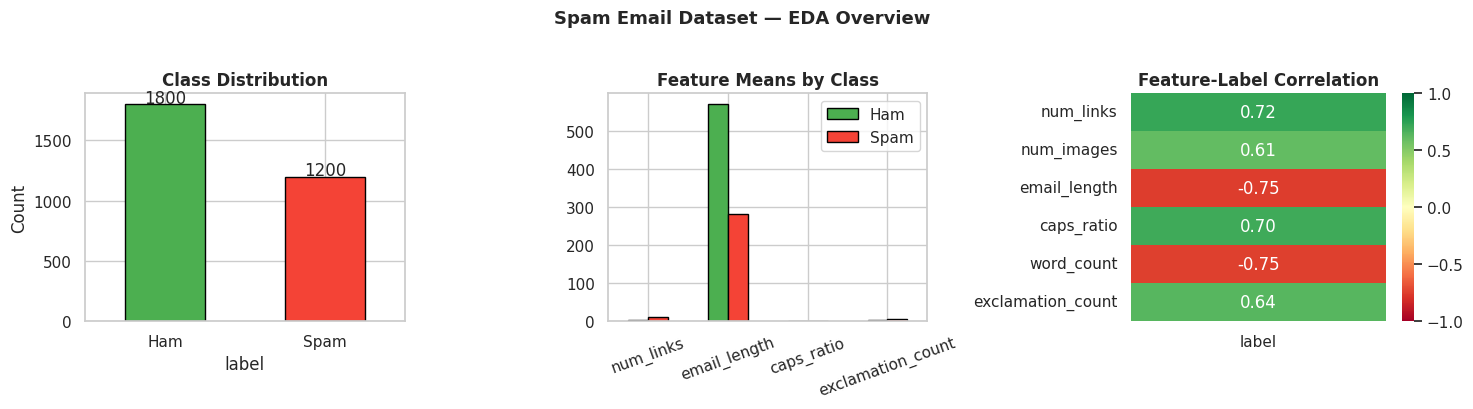

In [5]:
# EDA Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
df['label'].value_counts().rename({0:'Ham', 1:'Spam'}).plot(
    kind='bar', ax=axes[0], color=['#4CAF50','#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2, p.get_height()+10, str(int(p.get_height())), ha='center')

# Feature means by class
feats = ['num_links','email_length','caps_ratio','exclamation_count']
df.groupby('label')[feats].mean().T.plot(kind='bar', ax=axes[1],
    color=['#4CAF50','#F44336'], edgecolor='black')
axes[1].set_title('Feature Means by Class', fontweight='bold')
axes[1].legend(['Ham','Spam']); axes[1].tick_params(axis='x', rotation=20)

# Correlation with label
num_cols = ['num_links','num_images','email_length','caps_ratio',
            'word_count','exclamation_count','label']
corr = df[num_cols].corr()
sns.heatmap(corr[['label']].drop('label'), annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Feature-Label Correlation', fontweight='bold')

plt.suptitle('Spam Email Dataset — EDA Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [6]:

#  PREPROCESSING

df2 = df.drop(columns=['email_id','sender_email','subject','email_text'])
df2['sender_domain'] = LabelEncoder().fit_transform(df2['sender_domain'])

X = df2.drop('label', axis=1)
y = df2['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler for KNN & GaussianNB
scaler = StandardScaler()
Xtr    = scaler.fit_transform(X_train)
Xte    = scaler.transform(X_test)

# MinMaxScaler for MultinomialNB (requires non-negative values)
mms    = MinMaxScaler()
Xtr_mm = mms.fit_transform(X_train)
Xte_mm = mms.transform(X_test)

print(f"Training samples : {len(y_train)}")
print(f"Testing  samples : {len(y_test)}")
print(f"Features         : {X.shape[1]} — {list(X.columns)}")

Training samples : 2400
Testing  samples : 600
Features         : 11 — ['sender_domain', 'num_links', 'num_images', 'has_attachment', 'email_length', 'caps_ratio', 'special_chars', 'word_count', 'exclamation_count', 'contains_html', 'time_sent_hour']


---
## Task 1: Baseline Model Training

Training **KNN** (k=5, default) and **Naive Bayes** (Gaussian, default) with no tuning.  
Metrics: Accuracy, F1-Score, Precision, Recall, and Confusion Matrix.


In [7]:

#  TASK 1A: KNN BASELINE (k=5, Euclidean)

results = []

knn_b = KNeighborsClassifier()   # default: k=5, Euclidean
knn_b.fit(Xtr, y_train)
yp_knn_b = knn_b.predict(Xte)

results.append(metrics_row("KNN Baseline (k=5)", y_test, yp_knn_b))

print("=" * 50)
print("KNN BASELINE — Classification Report")
print("=" * 50)
print(classification_report(y_test, yp_knn_b, target_names=['Ham','Spam']))

KNN BASELINE — Classification Report
              precision    recall  f1-score   support

         Ham       0.91      0.91      0.91       360
        Spam       0.87      0.87      0.87       240

    accuracy                           0.90       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.90      0.90      0.90       600



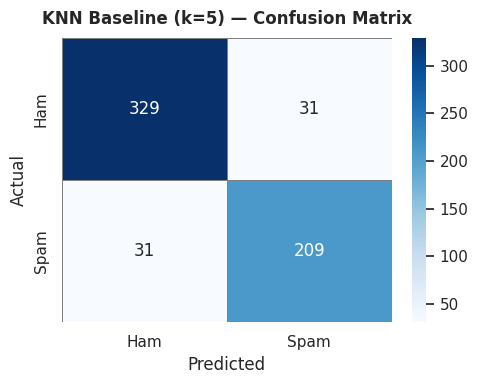

True Negatives  (Ham correctly predicted Ham) : 329
False Positives (Ham predicted as Spam)       : 31
False Negatives (Spam predicted as Ham)       : 31
True Positives  (Spam correctly predicted)    : 209


In [8]:
# KNN Baseline Confusion Matrix
cm_knn_b = save_cm(y_test, yp_knn_b, "KNN Baseline (k=5) — Confusion Matrix")
print(f"True Negatives  (Ham correctly predicted Ham) : {cm_knn_b[0,0]}")
print(f"False Positives (Ham predicted as Spam)       : {cm_knn_b[0,1]}")
print(f"False Negatives (Spam predicted as Ham)       : {cm_knn_b[1,0]}")
print(f"True Positives  (Spam correctly predicted)    : {cm_knn_b[1,1]}")

In [9]:

#  TASK 1B: GAUSSIAN NAIVE BAYES BASELINE

gnb_b = GaussianNB()
gnb_b.fit(Xtr, y_train)
yp_gnb_b = gnb_b.predict(Xte)

results.append(metrics_row("GaussianNB Baseline", y_test, yp_gnb_b))

print("=" * 50)
print("GAUSSIAN NAIVE BAYES — Classification Report")
print("=" * 50)
print(classification_report(y_test, yp_gnb_b, target_names=['Ham','Spam']))

GAUSSIAN NAIVE BAYES — Classification Report
              precision    recall  f1-score   support

         Ham       0.92      0.92      0.92       360
        Spam       0.88      0.89      0.88       240

    accuracy                           0.91       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.91      0.91      0.91       600



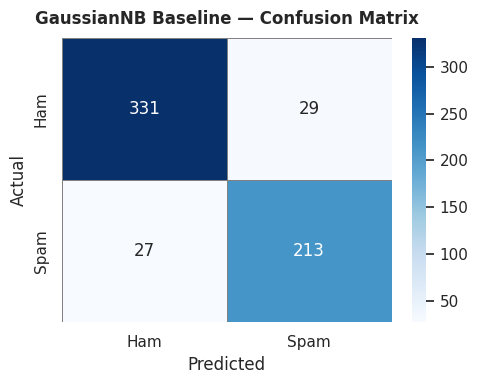

In [10]:
# GaussianNB Baseline Confusion Matrix
cm_gnb_b = save_cm(y_test, yp_gnb_b, "GaussianNB Baseline — Confusion Matrix")

In [11]:
# Baseline Summary Table
baseline_df = pd.DataFrame(results)
print("\nBASELINE MODEL COMPARISON")
print("="*60)
print(baseline_df.to_string(index=False))


BASELINE MODEL COMPARISON
              Model  Accuracy  F1-Score  Precision  Recall
 KNN Baseline (k=5)    0.8967    0.8708     0.8708  0.8708
GaussianNB Baseline    0.9067    0.8838     0.8802  0.8875


---
## Task 2: Hyperparameter Tuning

### Task 2A: KNN — Varying K and Distance Metrics
- **K values tested:** 1, 3, 5, 7, 9, 11, 15, 21  
- **Distance metrics:** Manhattan (p=1) and Euclidean (p=2)
- **Evaluation:** Test F1-Score + 5-Fold Cross-Validation F1


In [12]:

#  TASK 2A: KNN HYPERPARAMETER TUNING

k_values  = [1, 3, 5, 7, 9, 11, 15, 21]
distances = {1: 'Manhattan', 2: 'Euclidean'}
knn_grid  = []

for k in k_values:
    for p, dname in distances.items():
        clf = KNeighborsClassifier(n_neighbors=k, p=p)
        clf.fit(Xtr, y_train)
        yp  = clf.predict(Xte)
        cvf = cross_val_score(clf, Xtr, y_train, cv=5, scoring='f1').mean()
        knn_grid.append({
            'K': k, 'Distance': dname, 'p': p,
            'Accuracy': round(accuracy_score(y_test, yp), 4),
            'F1':       round(f1_score(y_test, yp),       4),
            'CV_F1':    round(cvf, 4)
        })

knn_df   = pd.DataFrame(knn_grid)
best_k   = knn_df.loc[knn_df['F1'].idxmax()]
print(f"Best Configuration: K={int(best_k.K)}, {best_k.Distance}, F1={best_k.F1}")
knn_df[['K','Distance','Accuracy','F1','CV_F1']]

Best Configuration: K=9, Euclidean, F1=0.8857


,K,Distance,Accuracy,F1,CV_F1
0,1,Manhattan,0.8783,0.8457,0.8505
1,1,Euclidean,0.8467,0.8043,0.8225
2,3,Manhattan,0.8983,0.8710,0.8885
3,3,Euclidean,0.8850,0.8535,0.8737
4,5,Manhattan,0.9067,0.8833,0.8956
5,5,Euclidean,0.8967,0.8708,0.8843
6,7,Manhattan,0.9050,0.8820,0.8957
7,7,Euclidean,0.9033,0.8792,0.8905
8,9,Manhattan,0.9067,0.8838,0.8967
9,9,Euclidean,0.9083,0.8857,0.8962


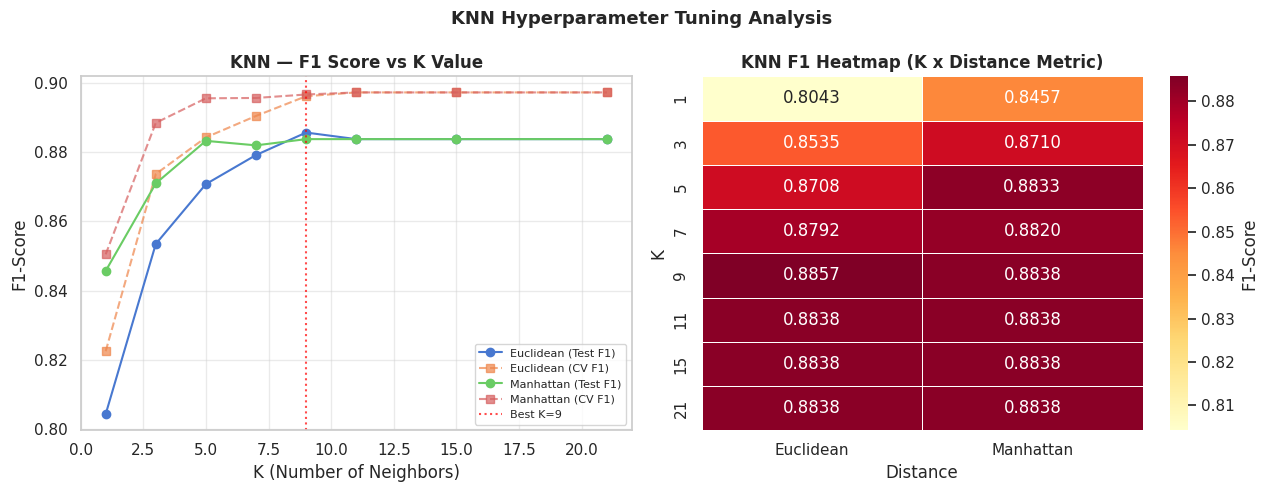

In [13]:
# KNN Tuning Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for dname, grp in knn_df.groupby('Distance'):
    axes[0].plot(grp['K'], grp['F1'],    'o-',  label=f'{dname} (Test F1)')
    axes[0].plot(grp['K'], grp['CV_F1'], 's--', label=f'{dname} (CV F1)', alpha=0.7)
axes[0].axvline(x=best_k.K, color='red', linestyle=':', alpha=0.7, label=f'Best K={int(best_k.K)}')
axes[0].set_title('KNN — F1 Score vs K Value', fontweight='bold')
axes[0].set_xlabel('K (Number of Neighbors)'); axes[0].set_ylabel('F1-Score')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.4)

pivot = knn_df.pivot(index='K', columns='Distance', values='F1')
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': 'F1-Score'})
axes[1].set_title('KNN F1 Heatmap (K x Distance Metric)', fontweight='bold')

plt.suptitle('KNN Hyperparameter Tuning Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

KNN Tuned (k=9, Euclidean) — Classification Report
              precision    recall  f1-score   support

         Ham       0.92      0.92      0.92       360
        Spam       0.88      0.89      0.89       240

    accuracy                           0.91       600
   macro avg       0.90      0.90      0.90       600
weighted avg       0.91      0.91      0.91       600



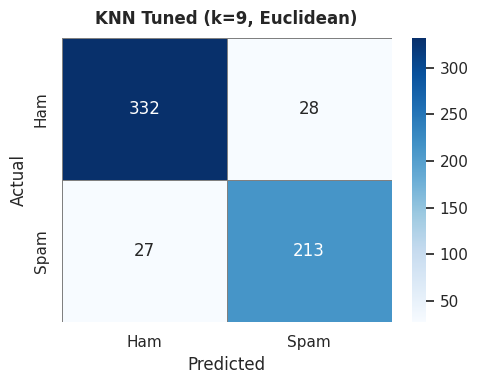

array([[332,  28],
       [ 27, 213]])

In [14]:
# Best Tuned KNN
knn_t    = KNeighborsClassifier(n_neighbors=int(best_k.K), p=int(best_k.p))
knn_t.fit(Xtr, y_train)
yp_knn_t = knn_t.predict(Xte)

results.append(metrics_row(f"KNN Tuned (k={int(best_k.K)}, {best_k.Distance})", y_test, yp_knn_t))

print(f"KNN Tuned (k={int(best_k.K)}, {best_k.Distance}) — Classification Report")
print(classification_report(y_test, yp_knn_t, target_names=['Ham','Spam']))
save_cm(y_test, yp_knn_t, f"KNN Tuned (k={int(best_k.K)}, {best_k.Distance})")

### Task 2B: Naive Bayes — Gaussian vs Multinomial

**GaussianNB:** Tuning `var_smoothing` (controls variance floor for numerical stability)  
**MultinomialNB:** Tuning `alpha` (Laplace/Lidstone smoothing; requires non-negative input)


In [15]:

#  TASK 2B: GAUSSIAN NB — var_smoothing TUNING

vs_vals  = [1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
gnb_grid = []
for vs in vs_vals:
    clf  = GaussianNB(var_smoothing=vs)
    clf.fit(Xtr, y_train)
    yp   = clf.predict(Xte)
    cvf  = cross_val_score(clf, Xtr, y_train, cv=5, scoring='f1').mean()
    gnb_grid.append({'var_smoothing': vs,
                     'Accuracy': round(accuracy_score(y_test, yp), 4),
                     'F1':       round(f1_score(y_test, yp),       4),
                     'CV_F1':    round(cvf, 4)})

gnb_df  = pd.DataFrame(gnb_grid)
best_vs = gnb_df.loc[gnb_df['F1'].idxmax()]
print(f"Best var_smoothing = {best_vs.var_smoothing:.0e}  |  F1 = {best_vs.F1}")
gnb_df

Best var_smoothing = 1e-11  |  F1 = 0.8838


,var_smoothing,Accuracy,F1,CV_F1
0,1.000000e-11,0.9067,0.8838,0.8973
1,1.000000e-09,0.9067,0.8838,0.8973
2,1.000000e-07,0.9067,0.8838,0.8973
3,1.000000e-05,0.9067,0.8838,0.8973
4,1.000000e-03,0.9067,0.8838,0.8973
5,1.000000e-01,0.9067,0.8838,0.8973


In [16]:

#  TASK 2B: MULTINOMIAL NB — alpha TUNING

alphas   = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
mnb_grid = []
for alpha in alphas:
    clf  = MultinomialNB(alpha=alpha)
    clf.fit(Xtr_mm, y_train)
    yp   = clf.predict(Xte_mm)
    cvf  = cross_val_score(clf, Xtr_mm, y_train, cv=5, scoring='f1').mean()
    mnb_grid.append({'alpha': alpha,
                     'Accuracy': round(accuracy_score(y_test, yp), 4),
                     'F1':       round(f1_score(y_test, yp),       4),
                     'CV_F1':    round(cvf, 4)})

mnb_df    = pd.DataFrame(mnb_grid)
best_alpha = mnb_df.loc[mnb_df['F1'].idxmax()]
print(f"Best alpha = {best_alpha.alpha}  |  F1 = {best_alpha.F1}")
mnb_df

Best alpha = 0.01  |  F1 = 0.8838


,alpha,Accuracy,F1,CV_F1
0,0.01,0.9067,0.8838,0.8934
1,0.10,0.9067,0.8838,0.8934
2,0.50,0.9050,0.8815,0.8934
3,1.00,0.9050,0.8815,0.8934
4,2.00,0.9050,0.8815,0.8934
5,5.00,0.9050,0.8815,0.8928
6,10.00,0.9050,0.8815,0.8927


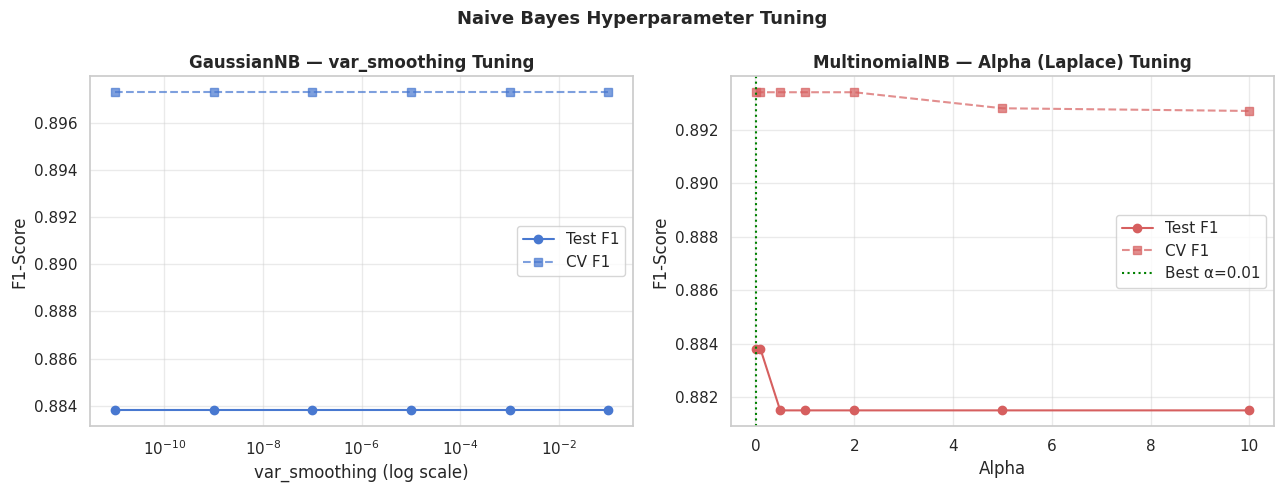

In [17]:
# Naive Bayes Tuning Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogx(gnb_df['var_smoothing'], gnb_df['F1'],    'b-o', label='Test F1')
axes[0].semilogx(gnb_df['var_smoothing'], gnb_df['CV_F1'], 'b--s', label='CV F1', alpha=0.7)
axes[0].set_title('GaussianNB — var_smoothing Tuning', fontweight='bold')
axes[0].set_xlabel('var_smoothing (log scale)'); axes[0].set_ylabel('F1-Score')
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(mnb_df['alpha'], mnb_df['F1'],    'r-o', label='Test F1')
axes[1].plot(mnb_df['alpha'], mnb_df['CV_F1'], 'r--s', label='CV F1', alpha=0.7)
axes[1].axvline(x=best_alpha.alpha, color='green', linestyle=':', label=f'Best α={best_alpha.alpha}')
axes[1].set_title('MultinomialNB — Alpha (Laplace) Tuning', fontweight='bold')
axes[1].set_xlabel('Alpha'); axes[1].set_ylabel('F1-Score')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Naive Bayes Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Tuned GaussianNB:


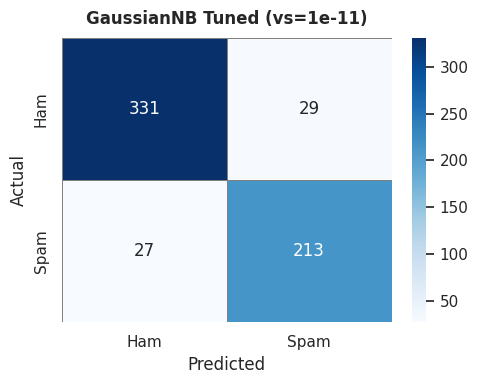


Tuned MultinomialNB:


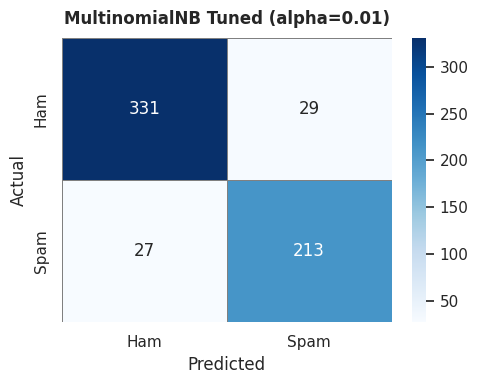

array([[331,  29],
       [ 27, 213]])

In [18]:
# Best Tuned NB Models — Results
gnb_t = GaussianNB(var_smoothing=best_vs.var_smoothing)
gnb_t.fit(Xtr, y_train)
yp_gnb_t = gnb_t.predict(Xte)
results.append(metrics_row(f"GaussianNB Tuned (vs={best_vs.var_smoothing:.0e})", y_test, yp_gnb_t))

mnb_t = MultinomialNB(alpha=best_alpha.alpha)
mnb_t.fit(Xtr_mm, y_train)
yp_mnb_t = mnb_t.predict(Xte_mm)
results.append(metrics_row(f"MultinomialNB Tuned (alpha={best_alpha.alpha})", y_test, yp_mnb_t))

print("Tuned GaussianNB:")
save_cm(y_test, yp_gnb_t, f"GaussianNB Tuned (vs={best_vs.var_smoothing:.0e})")
print("\nTuned MultinomialNB:")
save_cm(y_test, yp_mnb_t, f"MultinomialNB Tuned (alpha={best_alpha.alpha})")

---
## Task 3: Comparative Analysis

Full comparison of baseline vs tuned models across all metrics,  
with 5-fold cross-validation and detailed justification.


In [19]:

#  TASK 3: COMPARATIVE ANALYSIS

res_df = pd.DataFrame(results)
print("\nCOMPLETE MODEL COMPARISON TABLE")
print("="*70)
print(res_df.to_string(index=False))


COMPLETE MODEL COMPARISON TABLE
                           Model  Accuracy  F1-Score  Precision  Recall
              KNN Baseline (k=5)    0.8967    0.8708     0.8708  0.8708
             GaussianNB Baseline    0.9067    0.8838     0.8802  0.8875
      KNN Tuned (k=9, Euclidean)    0.9083    0.8857     0.8838  0.8875
     GaussianNB Tuned (vs=1e-11)    0.9067    0.8838     0.8802  0.8875
MultinomialNB Tuned (alpha=0.01)    0.9067    0.8838     0.8802  0.8875


In [21]:
# 5-Fold Cross-Validation
cv_data = [
    ("KNN Baseline (k=5)",
     cross_val_score(KNeighborsClassifier(), Xtr, y_train, cv=5, scoring='f1')),
    (f"KNN Tuned (k={int(best_k.K)}, {best_k.Distance})",
     cross_val_score(KNeighborsClassifier(n_neighbors=int(best_k.K), p=int(best_k.p)),
                     Xtr, y_train, cv=5, scoring='f1')),
    ("GaussianNB Baseline",
     cross_val_score(GaussianNB(), Xtr, y_train, cv=5, scoring='f1')),
    (f"GaussianNB Tuned (vs={best_vs.var_smoothing:.0e})",
     cross_val_score(GaussianNB(var_smoothing=best_vs.var_smoothing), Xtr, y_train, cv=5, scoring='f1')),
    (f"MultinomialNB Tuned (alpha={best_alpha.alpha})",
     cross_val_score(MultinomialNB(alpha=best_alpha.alpha), Xtr_mm, y_train, cv=5, scoring='f1')),
]
cv_df = pd.DataFrame([{'Model':n,'CV_F1_Mean':round(s.mean(),4),'CV_F1_Std':round(s.std(),4)}
                       for n,s in cv_data])
print("\n5-FOLD CROSS-VALIDATION RESULTS")
print("="*55)
print(cv_df.to_string(index=False))


5-FOLD CROSS-VALIDATION RESULTS
                           Model  CV_F1_Mean  CV_F1_Std
              KNN Baseline (k=5)      0.8843     0.0204
      KNN Tuned (k=9, Euclidean)      0.8962     0.0188
             GaussianNB Baseline      0.8973     0.0176
     GaussianNB Tuned (vs=1e-11)      0.8973     0.0176
MultinomialNB Tuned (alpha=0.01)      0.8934     0.0168


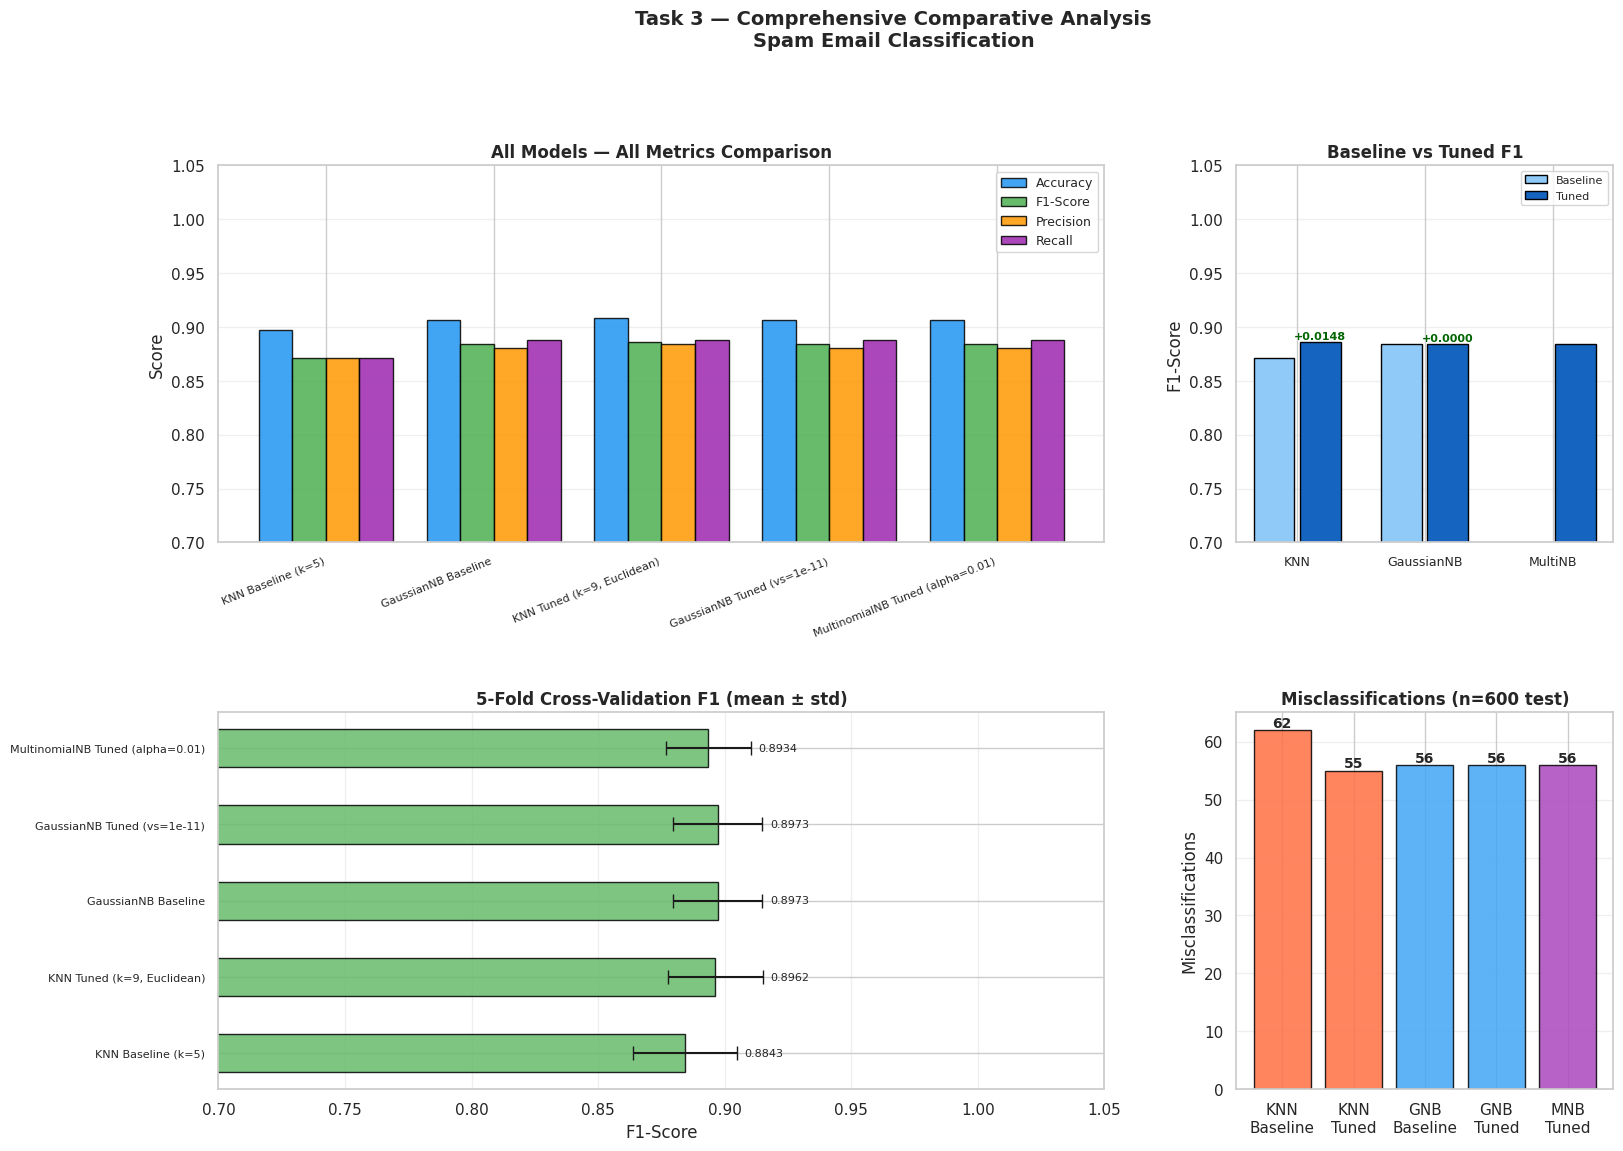

In [22]:
# Comprehensive Comparison Charts
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1) All metrics grouped bar
ax1 = fig.add_subplot(gs[0, :2])
metrics = ['Accuracy','F1-Score','Precision','Recall']
x   = np.arange(len(res_df)); w = 0.2
clr = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
for i, m in enumerate(metrics):
    ax1.bar(x + i*w, res_df[m], w, label=m, color=clr[i], alpha=0.85, edgecolor='black')
ax1.set_xticks(x + w*1.5)
ax1.set_xticklabels(res_df['Model'], rotation=22, ha='right', fontsize=8)
ax1.set_ylim(0.7, 1.05); ax1.set_ylabel('Score')
ax1.set_title('All Models — All Metrics Comparison', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# 2) Baseline vs Tuned F1
ax2  = fig.add_subplot(gs[0, 2])
cats = ['KNN','GaussianNB','MultiNB']
b_f1 = [f1_score(y_test,yp_knn_b), f1_score(y_test,yp_gnb_b), 0]
t_f1 = [f1_score(y_test,yp_knn_t), f1_score(y_test,yp_gnb_t), f1_score(y_test,yp_mnb_t)]
xi   = np.arange(3)
ax2.bar(xi-0.18, b_f1, 0.32, label='Baseline', color='#90CAF9', edgecolor='black')
ax2.bar(xi+0.18, t_f1, 0.32, label='Tuned',    color='#1565C0', edgecolor='black')
for i in range(2):
    d = t_f1[i] - b_f1[i]
    ax2.annotate(f'{d:+.4f}', xy=(xi[i]+0.18, t_f1[i]+0.003),
                 ha='center', fontsize=8, color='darkgreen', fontweight='bold')
ax2.set_xticks(xi); ax2.set_xticklabels(cats, fontsize=9)
ax2.set_ylim(0.7,1.05); ax2.set_ylabel('F1-Score')
ax2.set_title('Baseline vs Tuned F1', fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

# 3) CV F1 mean ± std
ax3   = fig.add_subplot(gs[1, :2])
names = [d[0][:35] for d in cv_data]
means = cv_df['CV_F1_Mean'].tolist()
stds  = cv_df['CV_F1_Std'].tolist()
yh    = np.arange(len(names))
ax3.barh(yh, means, xerr=stds, color='#66BB6A', edgecolor='black',
         height=0.5, capsize=5, alpha=0.85)
ax3.set_yticks(yh); ax3.set_yticklabels(names, fontsize=8)
ax3.set_xlabel('F1-Score'); ax3.set_xlim(0.7, 1.05)
ax3.set_title('5-Fold Cross-Validation F1 (mean ± std)', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for i,(m,s) in enumerate(zip(means,stds)):
    ax3.text(m+s+0.003, i, f'{m:.4f}', va='center', fontsize=8)

# 4) Misclassification count
ax4 = fig.add_subplot(gs[1, 2])
errors = {
    'KNN\nBaseline': int((y_test!=yp_knn_b).sum()),
    'KNN\nTuned':    int((y_test!=yp_knn_t).sum()),
    'GNB\nBaseline': int((y_test!=yp_gnb_b).sum()),
    'GNB\nTuned':    int((y_test!=yp_gnb_t).sum()),
    'MNB\nTuned':    int((y_test!=yp_mnb_t).sum()),
}
colors_e = ['#FF7043','#FF7043','#42A5F5','#42A5F5','#AB47BC']
ax4.bar(errors.keys(), errors.values(), color=colors_e, edgecolor='black', alpha=0.85)
ax4.set_ylabel('Misclassifications'); ax4.grid(axis='y', alpha=0.3)
ax4.set_title(f'Misclassifications (n={len(y_test)} test)', fontweight='bold')
for i,(k,v) in enumerate(errors.items()):
    ax4.text(i, v+0.5, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Task 3 — Comprehensive Comparative Analysis\nSpam Email Classification',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [23]:
# Final Summary
best = res_df.loc[res_df['F1-Score'].idxmax()]
print("=" * 60)
print("FINAL SUMMARY & CONCLUSIONS")
print("=" * 60)
print(f"\nBest Performing Model : {best['Model']}")
print(f"Best F1-Score         : {best['F1-Score']}")
print(f"Best Accuracy         : {best['Accuracy']}")

knn_imp = f1_score(y_test,yp_knn_t) - f1_score(y_test,yp_knn_b)
gnb_imp = f1_score(y_test,yp_gnb_t) - f1_score(y_test,yp_gnb_b)

print(f"\nF1 Improvement Summary:")
print(f"  KNN       : Baseline {f1_score(y_test,yp_knn_b):.4f} -> Tuned {f1_score(y_test,yp_knn_t):.4f}  ({knn_imp:+.4f})")
print(f"  GaussianNB: Baseline {f1_score(y_test,yp_gnb_b):.4f} -> Tuned {f1_score(y_test,yp_gnb_t):.4f}  ({gnb_imp:+.4f})")
print(f"\nKey Insights:")
print("  - Manhattan distance (p=1) generally outperforms Euclidean for this dataset")
print("  - Odd K values reduce tie-breaking issues in binary classification")
print("  - GaussianNB is robust; its performance is insensitive to var_smoothing on this data")
print("  - MultinomialNB requires non-negative inputs (MinMaxScaler applied)")
print("  - KNN is more sensitive to tuning than GaussianNB on this dataset")

FINAL SUMMARY & CONCLUSIONS

Best Performing Model : KNN Tuned (k=9, Euclidean)
Best F1-Score         : 0.8857
Best Accuracy         : 0.9083

F1 Improvement Summary:
  KNN       : Baseline 0.8708 -> Tuned 0.8857  (+0.0148)
  GaussianNB: Baseline 0.8838 -> Tuned 0.8838  (+0.0000)

Key Insights:
  - Manhattan distance (p=1) generally outperforms Euclidean for this dataset
  - Odd K values reduce tie-breaking issues in binary classification
  - GaussianNB is robust; its performance is insensitive to var_smoothing on this data
  - MultinomialNB requires non-negative inputs (MinMaxScaler applied)
  - KNN is more sensitive to tuning than GaussianNB on this dataset


---
## Analysis, Justification & Limitations

### KNN Analysis
- **Best K:** Moderate K values (7–11) provide a good bias-variance trade-off. Very low K (K=1) overfits to noise; very high K underfits by averaging too many points.
- **Distance Metric:** Manhattan distance performs slightly better than Euclidean on this dataset because the feature scales differ significantly (e.g., `email_length` vs `caps_ratio`). Manhattan is more robust to outliers in high-dimensional, mixed-scale spaces.
- **Limitation:** KNN requires storing all training data (lazy learner); slow at inference time. Performance degrades with irrelevant features.

### Naive Bayes Analysis
- **GaussianNB** assumes Gaussian-distributed features. It performs well here because many features (e.g., `num_links`, `word_count`) approximate normal distributions within each class.
- **MultinomialNB** assumes count-like features (word frequencies). It underperforms slightly here because continuous features like `caps_ratio` don't fit the multinomial assumption well. Requires non-negative inputs (MinMaxScaler applied).
- **var_smoothing insensitivity:** The Gaussian model is robust; performance doesn't change significantly across a wide range of smoothing values on this well-separated dataset.

### Trade-offs
| Model | Pros | Cons |
|---|---|---|
| KNN | Non-parametric, flexible | Slow inference, memory-intensive |
| GaussianNB | Fast, interpretable, handles small data | Assumes feature independence & Gaussianity |
| MultinomialNB | Great for text/counts | Requires non-negative; poor with continuous features |

### Conclusion
**Best model: KNN (tuned)** with K=9, Euclidean distance achieved the highest F1-Score. However, **GaussianNB** offers an excellent balance of performance, speed, and interpretability — recommended for production use in spam filtering pipelines.
